# Fitting a GAM to bike rental data

731 days of bike rentals in Washington DC, 2011-2012, from the UCI Bike Sharing daily
table. The question: how does temperature affect how many bikes get rented?

Fit a straight line and you get one slope, and one slope can only say "hotter is
better, forever". A GAM learns a curve instead, so it can climb and then come back
down, and you still get one readable curve per feature.

Three plots come out of this. Line vs curve, the temperature effect on its own, and
what the model claims about temperatures it has never seen.

Dataset: Fanaee-T, H. & Gama, J. (2013). Event labeling combining ensemble detectors
and background knowledge. Progress in Artificial Intelligence.

### Imports

In [1]:
# pip install -r requirements.txt

import io
import zipfile
import urllib.request
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

OUT = Path("figures")
OUT.mkdir(exist_ok=True)

RED   = "#DE3341"
NAVY  = "#2F3E5A"
GREY  = "#BEBEBE"
BAND  = "#EFF1F4"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})
print("matplotlib", matplotlib.__version__)

matplotlib 3.11.1


### Load data

UCI 403s some clients, so try the official zip first and fall back to a GitHub copy of
the same file. Cached as `day.csv` after the first run.

In [2]:
UCI_ZIP = "https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip"
MIRROR = ("https://raw.githubusercontent.com/danwild/bike-share-prediction/"
          "master/Bike-Sharing-Dataset/day.csv")


def load_bikes(path="day.csv") -> pd.DataFrame:
    # UCI Bike Sharing daily table, downloaded once and cached.
    p = Path(path)
    if p.exists():
        print(f"using cached {p}")
        return pd.read_csv(p)

    try:
        blob = urllib.request.urlopen(UCI_ZIP, timeout=30).read()
        with zipfile.ZipFile(io.BytesIO(blob)) as z:
            raw = z.read("day.csv")
        print("downloaded from UCI")
    except Exception as exc:                      # blocked or offline
        print(f"UCI unavailable ({type(exc).__name__}) - using GitHub mirror")
        raw = urllib.request.urlopen(MIRROR, timeout=30).read()

    p.write_bytes(raw)
    return pd.read_csv(io.BytesIO(raw))


bikes = load_bikes()
print(bikes.shape)
bikes.head(3)

using cached day.csv
(731, 16)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349


### Back to real units

UCI ships the weather columns scaled to 0-1, so a warm day shows up as 0.68 rather than
27.9 °C. Divisors: `temp / 41 C`, `atemp / 50 C`, `hum / 100 %`, `windspeed / 67 km/h`.

In [3]:
df = pd.DataFrame({
    "date":     pd.to_datetime(bikes["dteday"]),
    "temp_c":   bikes["temp"] * 41,
    "hum_pct":  bikes["hum"] * 100,
    "wind_kmh": bikes["windspeed"] * 67,
    "rides":    bikes["cnt"].astype(float),
})

print(f"{len(df)} days, {df.date.min():%b %Y} - {df.date.max():%b %Y}")
df[["temp_c", "hum_pct", "wind_kmh", "rides"]].describe().round(1)

731 days, Jan 2011 - Dec 2012


,temp_c,hum_pct,wind_kmh,rides
count,731.0,731.0,731.0,731.0
mean,20.3,62.8,12.8,4504.3
std,7.5,14.2,5.2,1937.2
min,2.4,0.0,1.5,22.0
25%,13.8,52.0,9.0,3152.0
50%,20.4,62.7,12.1,4548.0
75%,26.9,73.0,15.6,5956.0
max,35.3,97.2,34.0,8714.0


### Fit the GAM

`s(0)` puts a spline on temperature and `gridsearch` picks `lam`, the knob that decides
how wiggly the curve is allowed to get, by cross validation.

Keep an eye on the effective degrees of freedom in the output. At 1.0 the penalty has
flattened the curve into a straight line and the GAM has quietly become a linear model.

`np.polyfit` gives us a plain line to compare against.

In [4]:
from pygam import LinearGAM, s

X = df[["temp_c"]].to_numpy()
y = df["rides"].to_numpy()

gam = LinearGAM(s(0)).gridsearch(X, y, progress=False)
ols = np.polyfit(df.temp_c, df.rides, 1)

LO, HI = float(df.temp_c.min()), float(df.temp_c.max())
grid = np.linspace(LO, HI, 400)
fit = gam.predict(grid.reshape(-1, 1))
lo_ci, hi_ci = gam.confidence_intervals(grid.reshape(-1, 1), width=0.95).T

PEAK_C = float(grid[fit.argmax()])
PEAK_Y = float(fit.max())

print(f"lambda              {gam.lam[0][0]:,.2f}")
print(f"effective dof       {gam.statistics_['edof']:.2f}   (1.0 means a straight line)")
print(f"explained deviance  {gam.statistics_['pseudo_r2']['explained_deviance']:.3f}")
print(f"OLS R^2             {np.corrcoef(np.polyval(ols, df.temp_c), y)[0, 1] ** 2:.3f}")
print(f"observed range      {LO:.1f} - {HI:.1f} C")
print(f"peak                {PEAK_C:.1f} C  ->  {PEAK_Y:,.0f} rides/day")

lambda              15.85
effective dof       7.51   (1.0 means a straight line)
explained deviance  0.470
OLS R^2             0.394
observed range      2.4 - 35.3 C
peak                29.0 C  ->  5,749 rides/day


### Plot helpers

In [5]:
def canvas(rect=(0.115, 0.115, 0.86, 0.80)):
    fig = plt.figure(figsize=(17.5, 12.1), dpi=100)
    ax = fig.add_axes(rect)
    ax.grid(axis="y", color="#EDEDE7", lw=1.6)
    ax.set_axisbelow(True)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"):
        ax.spines[sp].set_color("#C9C9C9")
    ax.tick_params(labelsize=25, length=0)
    return fig, ax


def label(ax, xlab, ylab):
    ax.set_xlabel(xlab, fontsize=30, fontweight="bold", labelpad=12)
    ax.set_ylabel(ylab, fontsize=30, fontweight="bold", labelpad=12)


def save(fig, name):
    path = OUT / name
    fig.savefig(path, dpi=100)
    print("wrote", path)
    return path

### Linear vs GAM

The line can't do anything but keep climbing. The curve turns over. Shaded band is the
95% confidence interval on the fit.

wrote figures/01_linear_vs_gam.png


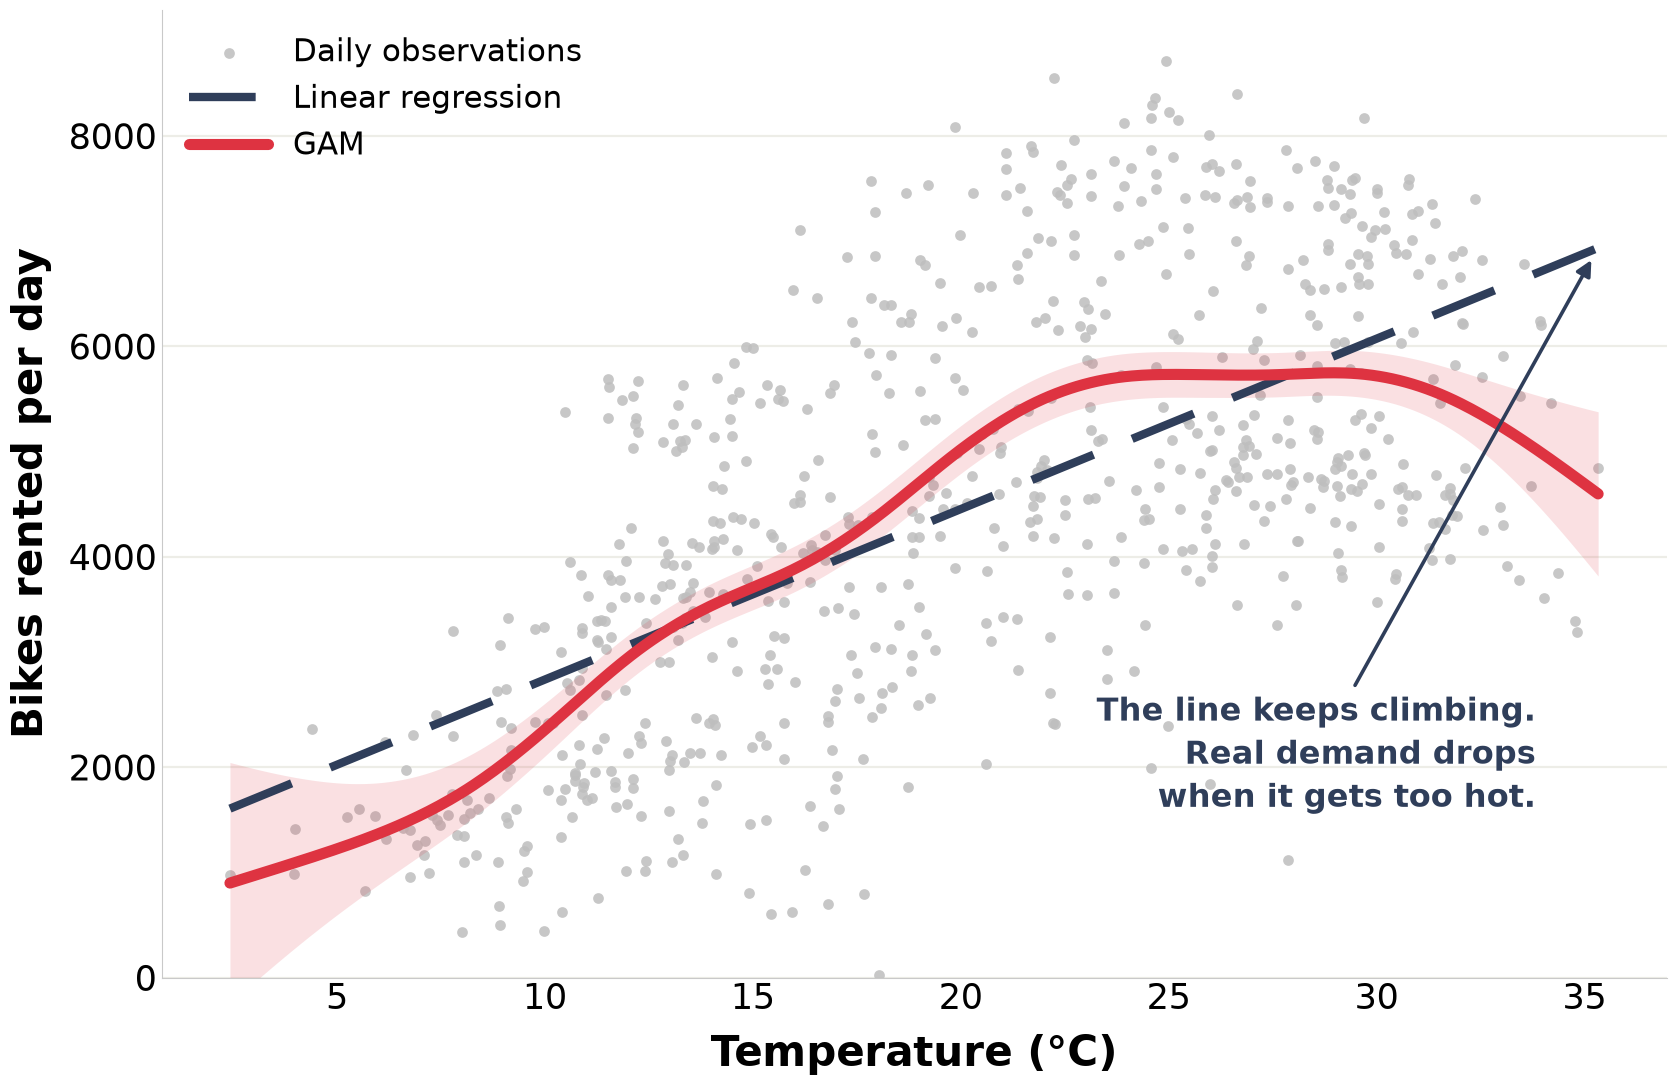

In [6]:
fig, ax = canvas()
ax.scatter(df.temp_c, df.rides, s=60, color=GREY, linewidths=0, alpha=.85,
           label="Daily observations")
ax.plot(grid, np.polyval(ols, grid), color=NAVY, lw=6, ls=(0, (8, 5)),
        label="Linear regression")
ax.fill_between(grid, lo_ci, hi_ci, color=RED, alpha=.15, lw=0)
ax.plot(grid, fit, color=RED, lw=8, solid_capstyle="round",
        label="GAM")

ax.annotate("The line keeps climbing.\nReal demand drops\nwhen it gets too hot.",
            xy=(HI, float(np.polyval(ols, HI))), xytext=(HI - 1.5, 1500),
            ha="right", va="bottom", fontsize=23, fontweight="bold",
            color=NAVY, linespacing=1.35,
            arrowprops=dict(arrowstyle="-|>", color=NAVY, lw=2.6, shrinkB=10))

label(ax, "Temperature (°C)", "Bikes rented per day")
ax.set_ylim(0, 9200)
ax.legend(loc="upper left", fontsize=22, frameon=False, handlelength=2.6)
save(fig, "01_linear_vs_gam.png")
plt.show()

### The temperature effect on its own

`partial_dependence` returns the curve centred on zero: rides added or removed relative
to an average day. Nothing told it where the peak was. No bins, no polynomial degree.

wrote figures/02_partial_effect.png


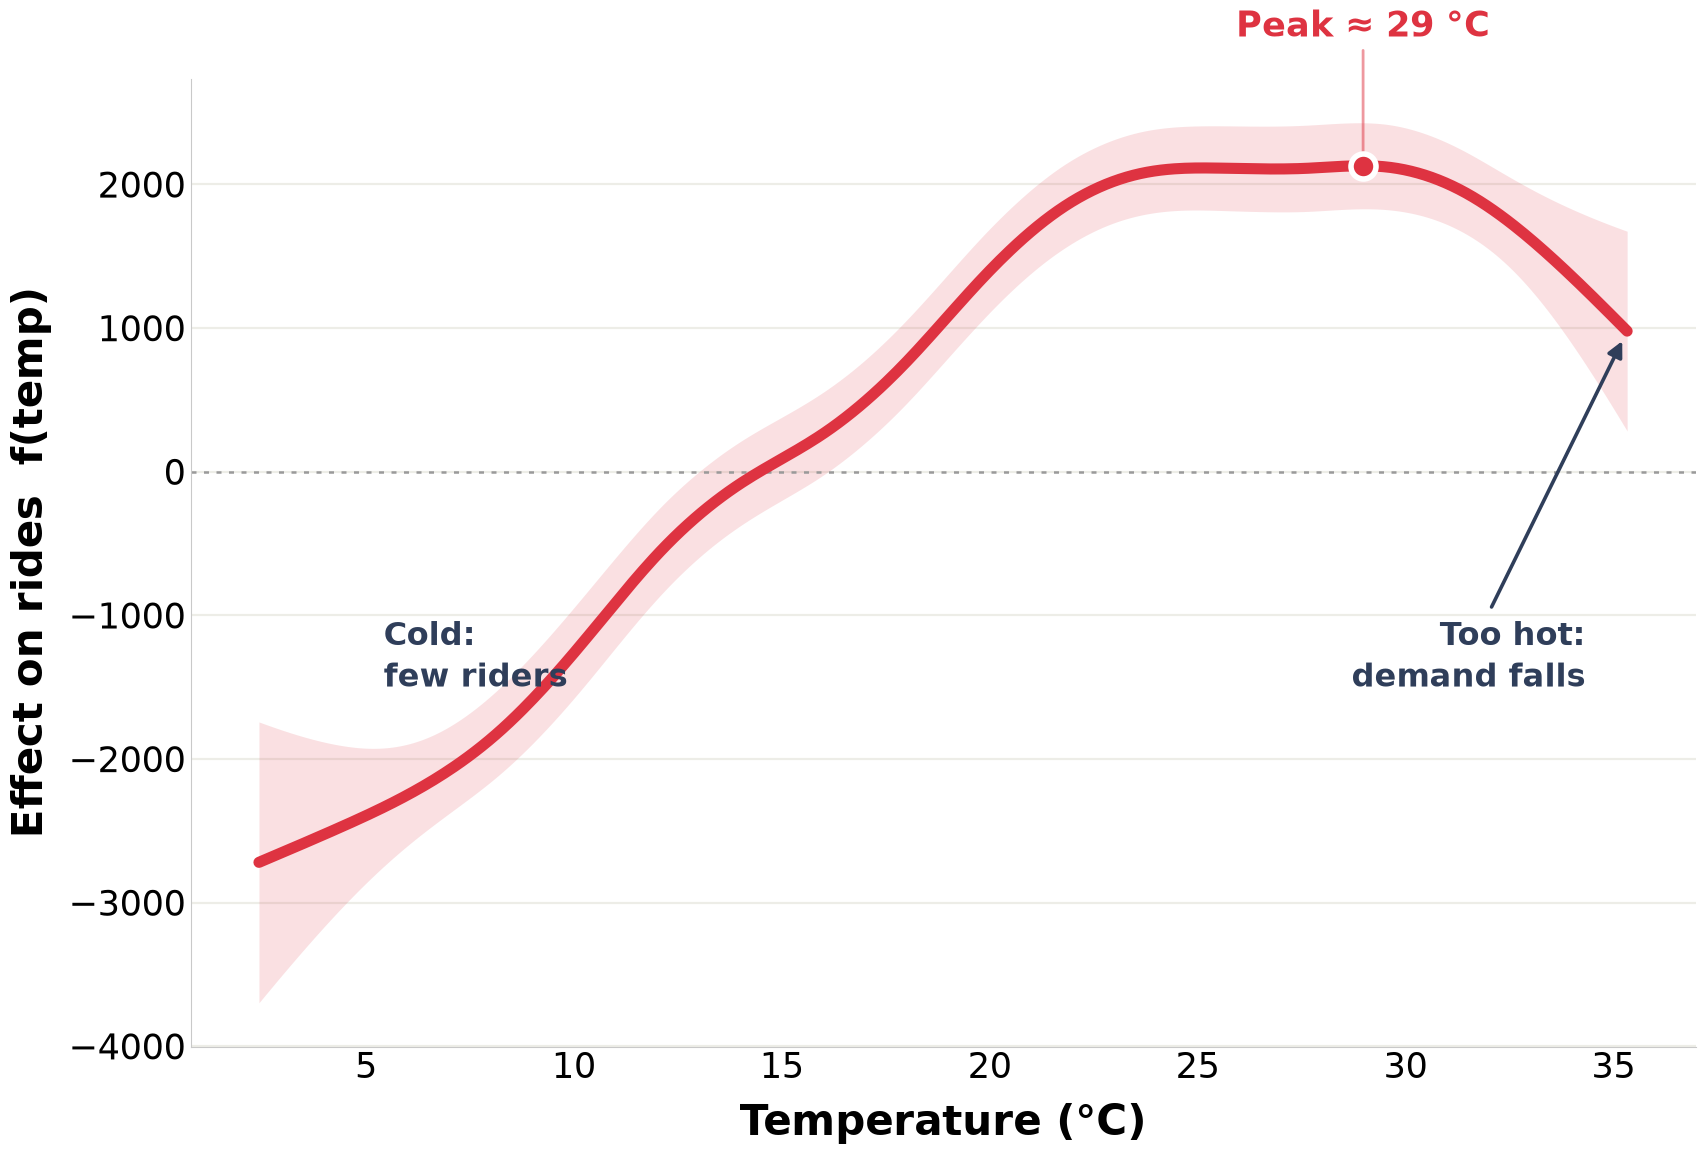

f(temp) spans -2,720 to 2,130 rides/day
crosses zero near 14.5 °C


In [7]:
XX = gam.generate_X_grid(term=0, n=400)
pdep, conf = gam.partial_dependence(term=0, X=XX, width=0.95)
tx = XX[:, 0]
pk = float(tx[pdep.argmax()])

fig, ax = canvas()
ax.axhline(0, color="#9A9A9A", lw=1.8, ls=(0, (2, 3)))
ax.fill_between(tx, conf[:, 0], conf[:, 1], color=RED, alpha=.15, lw=0)
ax.plot(tx, pdep, color=RED, lw=8, solid_capstyle="round")
ax.plot([pk], [pdep.max()], "o", ms=18, color=RED,
        markeredgecolor="white", markeredgewidth=4, zorder=5)

ax.annotate(f"Peak ≈ {pk:.0f} °C", xy=(pk, pdep.max()),
            xytext=(pk, pdep.max() + 900), ha="center", fontsize=25,
            fontweight="bold", color=RED,
            arrowprops=dict(arrowstyle="-", color=RED, lw=2, alpha=.5))
ax.text(LO + 3, pdep.min() * .55, "Cold:\nfew riders", fontsize=23,
        fontweight="bold", color=NAVY, linespacing=1.3)
ax.annotate("Too hot:\ndemand falls", xy=(HI, pdep[-1]),
            xytext=(HI - 1, pdep.min() * .55), ha="right", fontsize=23,
            fontweight="bold", color=NAVY, linespacing=1.3,
            arrowprops=dict(arrowstyle="-|>", color=NAVY, lw=2.6, shrinkB=8))

label(ax, "Temperature (°C)", "Effect on rides  f(temp)")
save(fig, "02_partial_effect.png")
plt.show()

print(f"f(temp) spans {pdep.min():,.0f} to {pdep.max():,.0f} rides/day")
print(f"crosses zero near {tx[np.argmin(np.abs(pdep))]:.1f} °C")

### Outside the data range

Splines have linear tails. Past the outer knots the curve carries on at whatever slope
it had at the edge, nothing knows rentals can't be negative, and you get no warning.

pyGAM won't predict outside the observed range by default, so refit with `edge_knots`
set by hand to force it.

In [8]:
XMIN, XMAX = -12.0, 55.0

gam_ext = LinearGAM(
    s(0, n_splines=gam.terms[0].n_splines, lam=gam.lam[0][0], edge_knots=[LO, HI])
).fit(X, y)


def predict(t):
    t = np.atleast_1d(t).astype(float)
    return gam_ext.predict(t.reshape(-1, 1))


def zero_crossing(a, b):
    t = np.linspace(a, b, 20_000)
    idx = np.where(np.diff(np.sign(predict(t))) != 0)[0]
    return float(t[idx[0]]) if len(idx) else float("nan")


cold_zero, hot_zero = zero_crossing(XMIN, LO), zero_crossing(HI, XMAX)
cold_x, hot_x = XMIN + 2, XMAX - 2

print(f"crosses zero at {cold_zero:.1f} °C and {hot_zero:.1f} °C")
print(f"{cold_x:>5.0f} °C -> {predict(cold_x)[0]:>8,.0f} rides/day")
print(f"{hot_x:>5.0f} °C -> {predict(hot_x)[0]:>8,.0f} rides/day")

crosses zero at -4.9 °C and 51.1 °C
  -10 °C ->     -624 rides/day
   53 °C ->     -560 rides/day


wrote

 figures/03_extrapolation.png


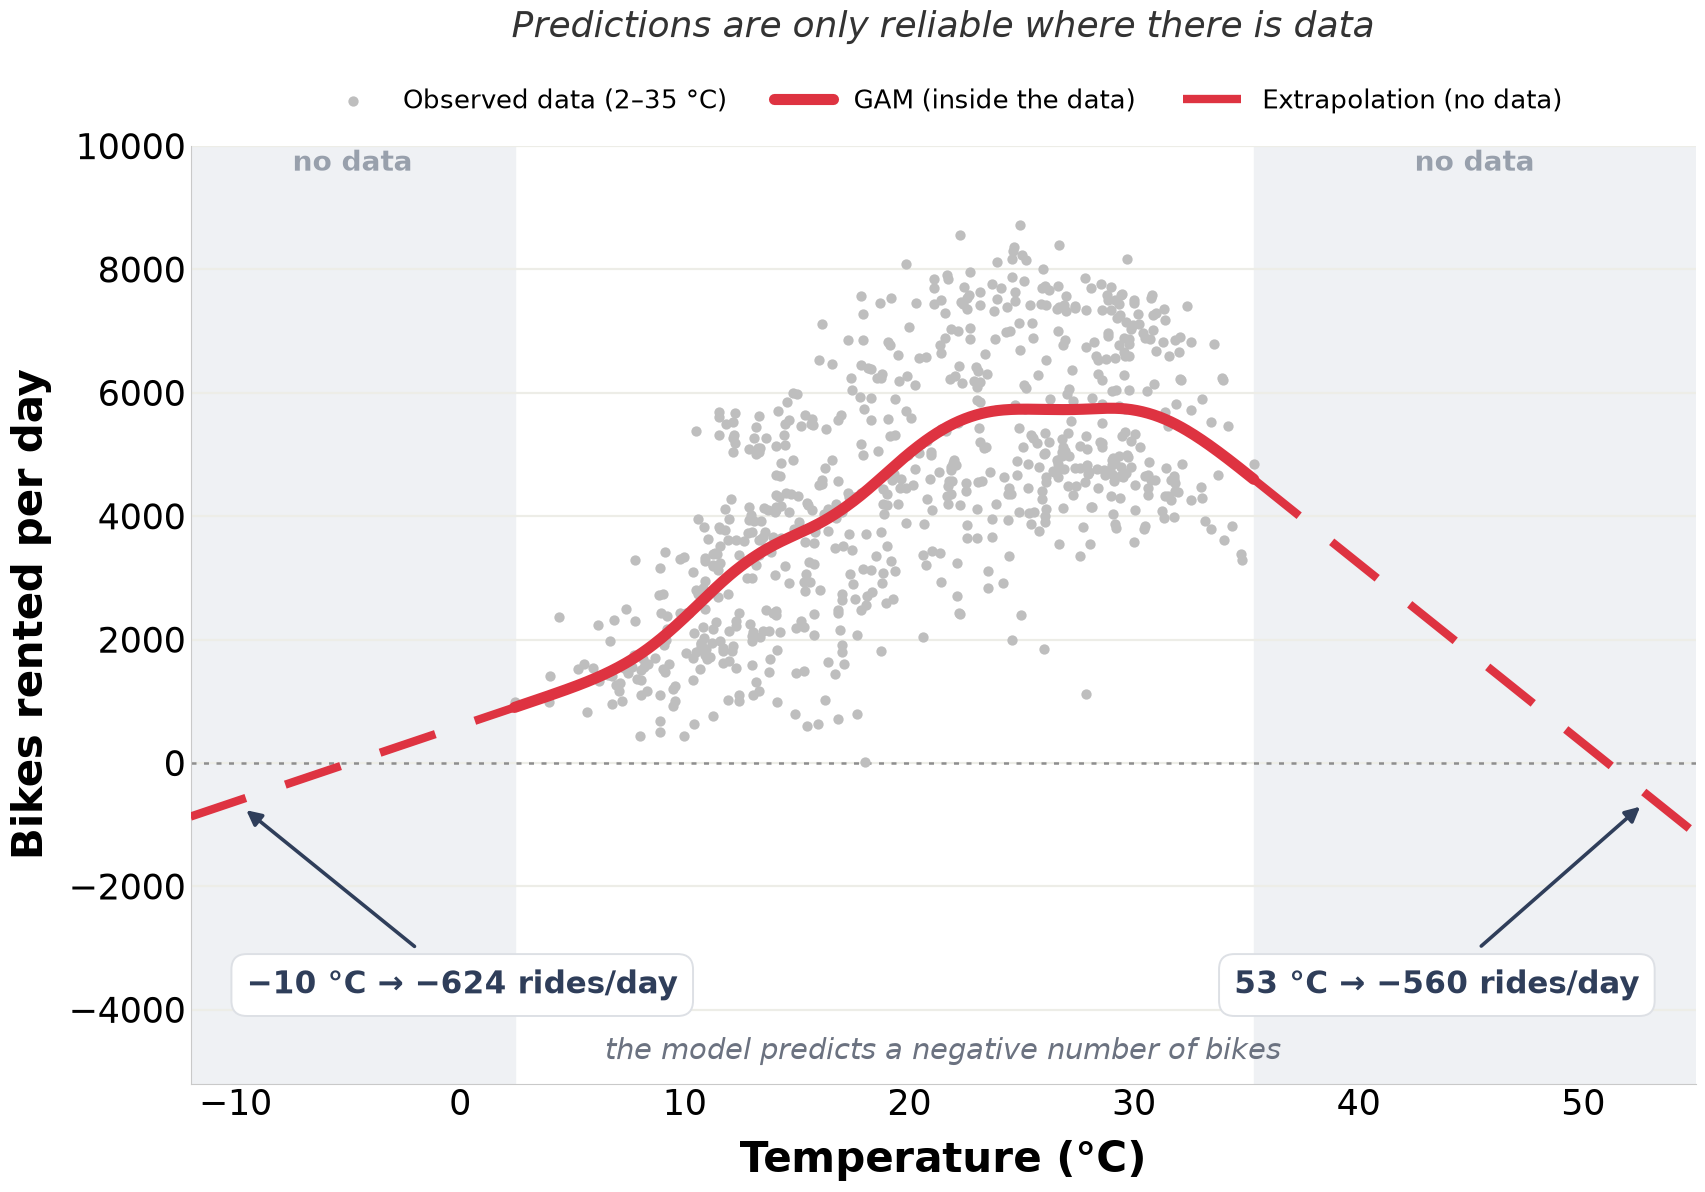

In [9]:
g_in   = np.linspace(LO, HI, 400)
g_cold = np.linspace(XMIN, LO, 200)
g_hot  = np.linspace(HI, XMAX, 200)

fig, ax = canvas(rect=(0.115, 0.10, 0.86, 0.775))
ax.axvspan(XMIN, LO, color=BAND, zorder=0)
ax.axvspan(HI, XMAX, color=BAND, zorder=0)
ax.axhline(0, color="#8E8E8E", lw=1.8, ls=(0, (2, 3)), zorder=2)

ax.scatter(df.temp_c, df.rides, s=55, color=GREY, linewidths=0, zorder=3,
           label=f"Observed data ({LO:.0f}–{HI:.0f} °C)")
ax.plot(g_in, predict(g_in), color=RED, lw=8, solid_capstyle="round", zorder=5,
        label="GAM (inside the data)")
ax.plot(g_cold, predict(g_cold), color=RED, lw=6, ls=(0, (7, 5)), zorder=4,
        label="Extrapolation (no data)")
ax.plot(g_hot, predict(g_hot), color=RED, lw=6, ls=(0, (7, 5)), zorder=4)

for xc in ((XMIN + LO) / 2, (HI + XMAX) / 2):
    ax.text(xc, 9600, "no data", ha="center", fontsize=20, fontweight="bold",
            color="#98A0AC")

box = dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="#DDE0E5", lw=1.4)
arrow = dict(arrowstyle="-|>", color=NAVY, lw=2.6, shrinkA=8, shrinkB=10)


def num(v):                       # minus sign, not a hyphen
    return f"{v:,.0f}".replace("-", "−")


ax.annotate(f"{num(cold_x)} °C → {num(predict(cold_x)[0])} rides/day",
            xy=(cold_x, predict(cold_x)[0]), xytext=(XMIN + 2.5, -3600),
            ha="left", va="center", fontsize=22, fontweight="bold",
            color=NAVY, bbox=box, arrowprops=arrow)
ax.annotate(f"{num(hot_x)} °C → {num(predict(hot_x)[0])} rides/day",
            xy=(hot_x, predict(hot_x)[0]), xytext=(XMAX - 2.5, -3600),
            ha="right", va="center", fontsize=22, fontweight="bold",
            color=NAVY, bbox=box, arrowprops=arrow)
ax.text((XMIN + XMAX) / 2, -4800, "the model predicts a negative number of bikes",
        ha="center", fontsize=21, style="italic", color="#6B7280")

label(ax, "Temperature (°C)", "Bikes rented per day")
ax.set_xlim(XMIN, XMAX)
ax.set_ylim(-5200, 10000)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.008), ncol=3, fontsize=19,
          frameon=False, handlelength=2.2, columnspacing=1.8)
fig.text(0.545, 0.965, "Predictions are only reliable where there is data",
         ha="center", fontsize=26, style="italic", color="#333333")
save(fig, "03_extrapolation.png")
plt.show()

### Every number this notebook quotes

In [10]:
facts = pd.DataFrame([
    ("days in dataset",          f"{len(df)}"),
    ("observed range",           f"{LO:.1f} – {HI:.1f} °C"),
    ("peak temperature",         f"{PEAK_C:.1f} °C"),
    ("rides at the peak",        f"{PEAK_Y:,.0f} / day"),
    ("lambda (GCV)",             f"{gam.lam[0][0]:,.2f}"),
    ("effective dof",            f"{gam.statistics_['edof']:.2f}"),
    ("explained deviance",       f"{gam.statistics_['pseudo_r2']['explained_deviance']:.1%}"),
    ("extrapolation hits zero",  f"{cold_zero:.1f} °C and {hot_zero:.1f} °C"),
    (f"prediction at {cold_x:.0f} °C", f"{predict(cold_x)[0]:,.0f} rides"),
    (f"prediction at {hot_x:.0f} °C",  f"{predict(hot_x)[0]:,.0f} rides"),
], columns=["quantity", "value"])
facts

,quantity,value
0,days in dataset,731
1,observed range,2.4 – 35.3 °C
2,peak temperature,29.0 °C
3,rides at the peak,"5,749 / day"
4,lambda (GCV),15.85
5,effective dof,7.51
6,explained deviance,47.0%
7,extrapolation hits zero,-4.9 °C and 51.1 °C
8,prediction at -10 °C,-624 rides
9,prediction at 53 °C,-560 rides


### Next steps

* More features. `LinearGAM(s(0) + s(1) + s(2))` on temperature, humidity and wind gets
  explained deviance from roughly 47% to 60%, and each one still gets its own curve.
  The temperature peak shifts a couple of degrees cooler once humidity is in there,
  since hot days in DC are also humid and the single feature fit was absorbing that.
* Categories. `f(3)` for columns like `weathersit`.
* Interactions aren't free. A GAM adds each feature separately, so a real temperature x
  humidity effect needs a tensor term, `te(0, 1)`.
* Counts. `PoissonGAM` suits ride counts better and won't go negative inside the data
  range, though it still extrapolates badly outside it.